In [50]:
import pandas as pd
import missingno as msno
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier 
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import train_test_split
from category_encoders import TargetEncoder
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV
import pickle
from sklearn.pipeline import Pipeline
import joblib

In [2]:
df = pd.read_csv('D:/НЕудалять PANDAS И ПРОЧЕЕ/ФИНАЛЬНЫЙ ПРОЕКТ/ga_hits-001.csv')
df1 = pd.read_csv('D:/НЕудалять PANDAS И ПРОЧЕЕ/ФИНАЛЬНЫЙ ПРОЕКТ/ga_sessions.csv')

C:\Users\Тарас\AppData\Local\Temp\ipykernel_11888\4011473579.py:2: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df1 = pd.read_csv('D:/НЕудалять PANDAS И ПРОЧЕЕ/ФИНАЛЬНЫЙ ПРОЕКТ/ga_sessions.csv')


In [3]:
df.head()

,session_id,hit_date,hit_time,hit_number,hit_type,hit_referer,hit_page_path,event_category,event_action,event_label,event_value
0,5639623078712724064.1640254056.1640254056,2021-12-23,597864.0,30,event,NaN,sberauto.com/cars?utm_source_initial=google&ut...,quiz,quiz_show,NaN,NaN
1,7750352294969115059.1640271109.1640271109,2021-12-23,597331.0,41,event,NaN,sberauto.com/cars/fiat?city=1&city=18&rental_c...,quiz,quiz_show,NaN,NaN
2,885342191847998240.1640235807.1640235807,2021-12-23,796252.0,49,event,NaN,sberauto.com/cars/all/volkswagen/polo/e994838f...,quiz,quiz_show,NaN,NaN
3,142526202120934167.1640211014.1640211014,2021-12-23,934292.0,46,event,NaN,sberauto.com/cars?utm_source_initial=yandex&ut...,quiz,quiz_show,NaN,NaN
4,3450086108837475701.1640265078.1640265078,2021-12-23,768741.0,79,event,NaN,sberauto.com/cars/all/mercedes-benz/cla-klasse...,quiz,quiz_show,NaN,NaN


**DataPreparation**

In [4]:
df['event_value'] = (df['event_action'].str.startswith('sub').astype(bool)).astype(int)

In [5]:
df1 = df1.merge(df[['session_id', 'event_value']], on = 'session_id', how = 'inner')

In [6]:
df1 = df1.drop_duplicates(subset = ['session_id'])

In [7]:
df1.head()

,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city,event_value
0,9055434745589932991.1637753792.1637753792,2108382700.163776,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Zlatoust,1
2,905544597018549464.1636867290.1636867290,210838531.163687,2021-11-14,08:21:30,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,NaN,385x854,Samsung Internet,Russia,Moscow,1
3,9055446045651783499.1640648526.1640648526,2108385331.164065,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Krasnoyarsk,0
19,9055447046360770272.1622255328.1622255328,2108385564.162225,2021-05-29,05:00:00,1,kjsLglQLzykiRbcDiGcD,cpc,NaN,NOBKLgtuvqYWkXQHeYWM,NaN,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow,1
22,9055447046360770272.1622255345.1622255345,2108385564.162225,2021-05-29,05:00:00,2,kjsLglQLzykiRbcDiGcD,cpc,NaN,NaN,NaN,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow,0


In [8]:
df1[df1.duplicated()]

,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city,event_value


In [9]:
def nan_med(df, col):
    st_med = df[col].median()
    df[col] = df[col].fillna(st_med)
    return df
    
    
    

In [10]:
def nan_mod(df, col):
    st_mod = df[col].mode()[0]
    df[col] = df[col].fillna(st_mod)
    return df
    

In [11]:
nan_mod(df1, 'utm_source')
nan_mod(df1, 'utm_campaign')
nan_mod(df1, 'utm_medium')
nan_mod(df1, 'device_brand')
nan_mod(df1, 'utm_keyword')
nan_mod(df1, 'utm_adcontent')

,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city,event_value
0,9055434745589932991.1637753792.1637753792,2108382700.163776,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Zlatoust,1
2,905544597018549464.1636867290.1636867290,210838531.163687,2021-11-14,08:21:30,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,NaN,385x854,Samsung Internet,Russia,Moscow,1
3,9055446045651783499.1640648526.1640648526,2108385331.164065,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Krasnoyarsk,0
19,9055447046360770272.1622255328.1622255328,2108385564.162225,2021-05-29,05:00:00,1,kjsLglQLzykiRbcDiGcD,cpc,LTuZkdKfxRGVceoWkVyg,NOBKLgtuvqYWkXQHeYWM,puhZPIYqKXeFPaUviSjo,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow,1
22,9055447046360770272.1622255345.1622255345,2108385564.162225,2021-05-29,05:00:00,2,kjsLglQLzykiRbcDiGcD,cpc,LTuZkdKfxRGVceoWkVyg,JNHcPlZPxEMWDnRiyoBf,puhZPIYqKXeFPaUviSjo,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15685150,9055415581448263752.1640159305.1640159305,2108378238.164016,2021-12-22,10:48:25,1,BHcvLfOaCWvWTykYqHVe,cpc,LTuZkdKfxRGVceoWkVyg,JNHcPlZPxEMWDnRiyoBf,VlqBmecIOXWjCWUmQkLd,desktop,Windows,Apple,NaN,1920x1080,Chrome,Russia,Moscow,1
15685152,9055421130527858185.1622007305.1622007305,2108379530.162201,2021-05-26,08:00:00,1,fDLlAcSmythWSCVMvqvL,(none),LTuZkdKfxRGVceoWkVyg,JNHcPlZPxEMWDnRiyoBf,puhZPIYqKXeFPaUviSjo,mobile,NaN,Apple,NaN,390x844,Safari,Russia,Stavropol,1
15685163,9055422955903931195.1636979515.1636979515,2108379955.163697,2021-11-15,15:31:55,1,fDLlAcSmythWSCVMvqvL,(none),LTuZkdKfxRGVceoWkVyg,JNHcPlZPxEMWDnRiyoBf,puhZPIYqKXeFPaUviSjo,mobile,iOS,Apple,NaN,375x667,Safari,Russia,Moscow,0
15685204,905543020766873816.1638189404.1638189404,210838164.163819,2021-11-29,15:36:44,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,JNHcPlZPxEMWDnRiyoBf,puhZPIYqKXeFPaUviSjo,mobile,Android,Xiaomi,NaN,393x851,Chrome,Russia,Chelyabinsk,1


In [12]:
group_med_1 = df1.groupby(['device_brand', 'device_category'])['device_model'].agg(lambda x: x.mode()[0] if len(x.mode()) > 0 else None)
mode_device = df1['device_model'].mode()[0] 
df1['device_model'] = df1['device_model'].fillna(df1[['device_brand', 'device_category']].apply(tuple,axis = 1).map(group_med_1)).fillna(mode_device)


In [13]:
med_os = df1.groupby(['device_brand', 'device_model'])['device_os'].agg(lambda x: x.mode()[0] if len(x.mode()) > 0 else None)
mode_os = df1['device_os'].mode()[0]
df1['device_os'] = df1['device_os'].fillna(df1[['device_brand', 'device_model']].apply(tuple, axis = 1).map(med_os)).fillna(mode_os)

<Axes: >

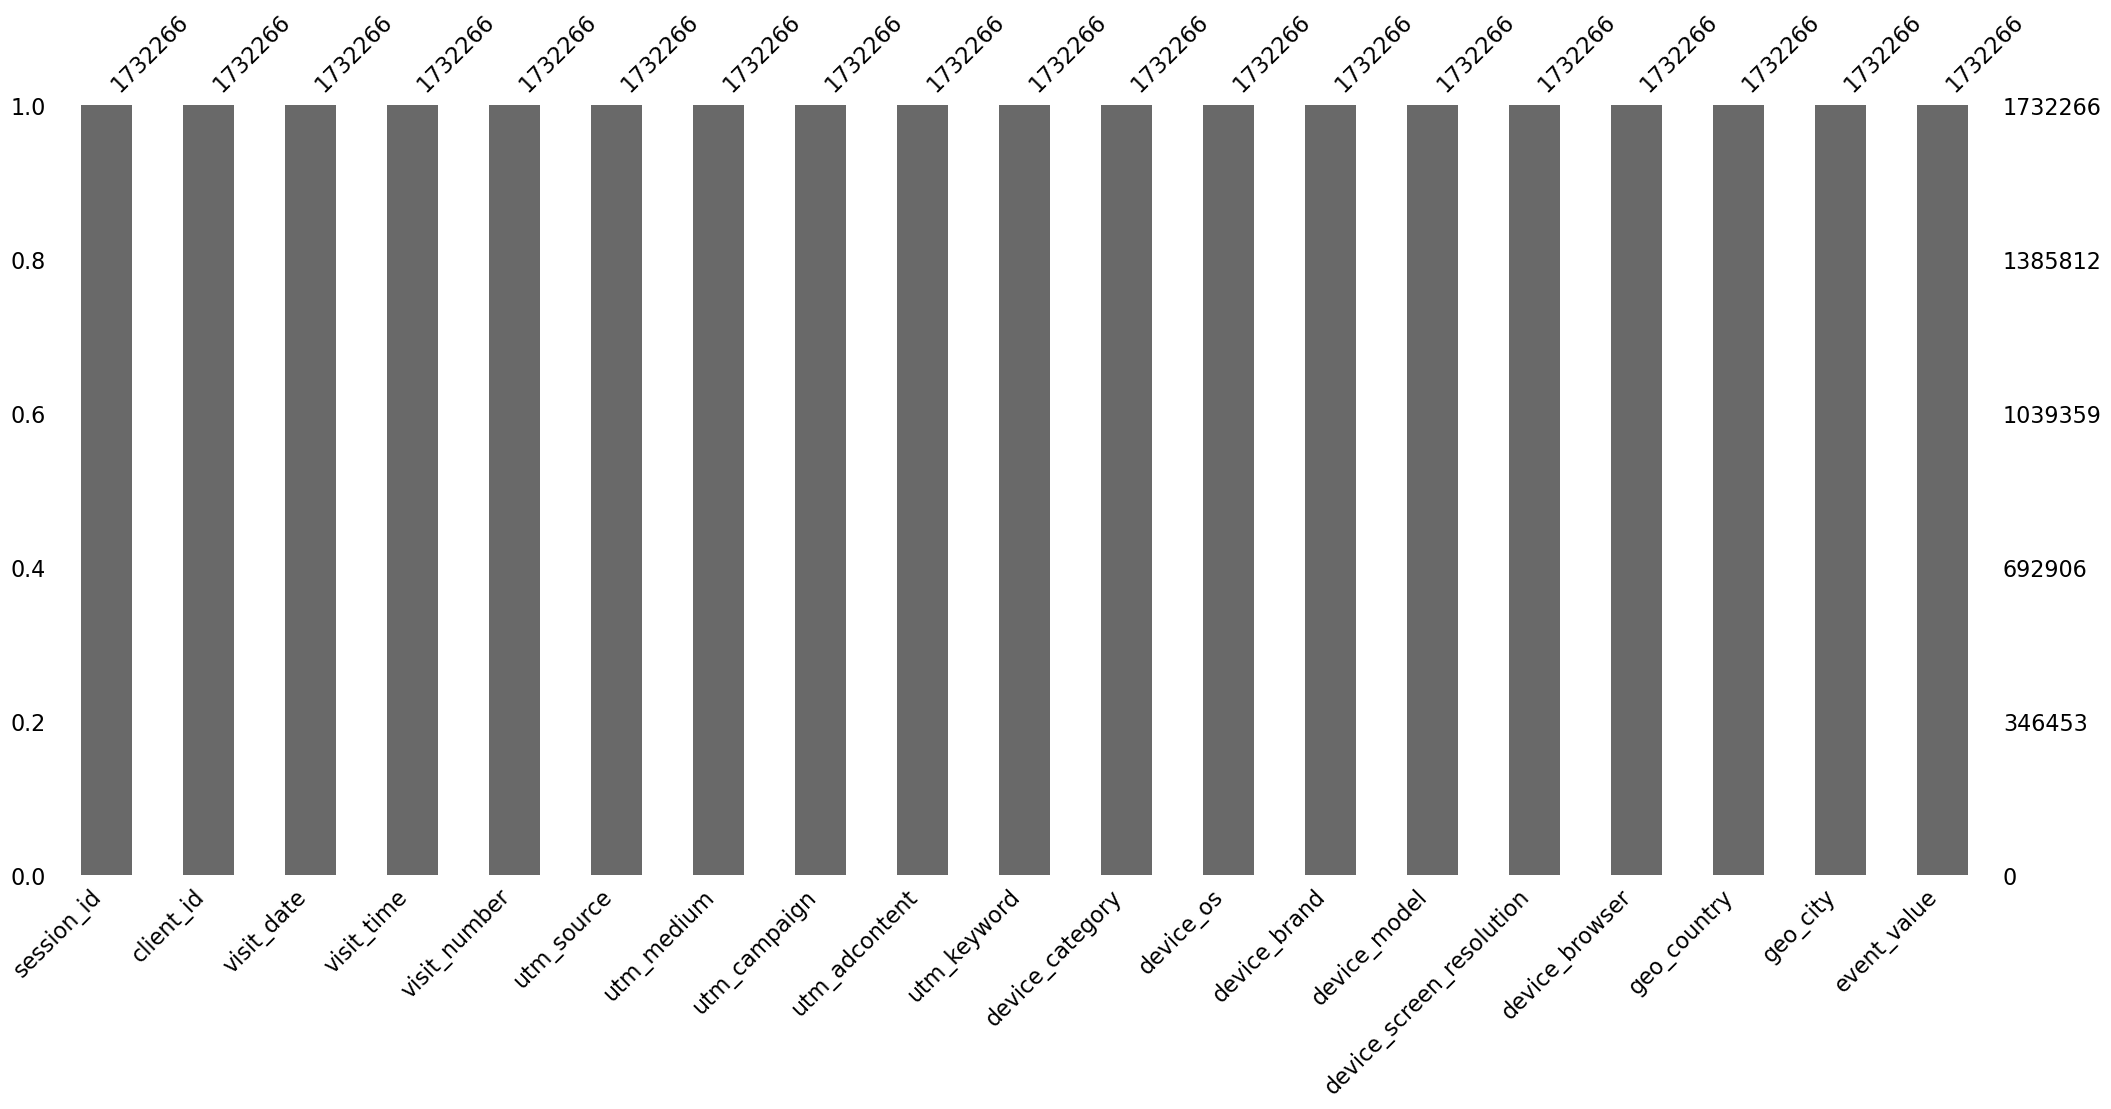

In [14]:
msno.bar(df1)

In [15]:
feauters = ['utm_source', 'utm_medium', 'utm_campaign', 'utm_adcontent', 'utm_keyword',	
    'device_category', 'device_os',	'device_brand',	'device_model',	
    'device_screen_resolution',	'device_browser', 'geo_country', 'geo_city']

In [16]:
encoder = TargetEncoder(smoothing = 10)
x1 = df1[feauters]
y1 = df1['event_value']
x1_train, x1_test, y1_train, y1_test = train_test_split(x1, y1, test_size = 0.2, random_state = 42)
x_analyse_enc = encoder.fit_transform(x1_train, y1_train)
x_analyse_enc['target'] = df1['event_value']

**Visualization**

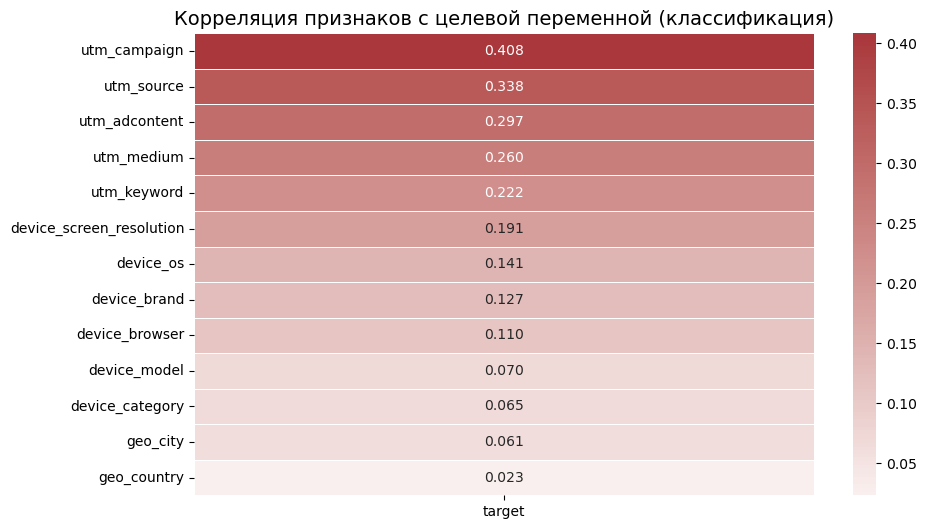

In [17]:
correl = x_analyse_enc.corr()['target'].drop('target').sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.heatmap(correl.to_frame(), 
            annot=True, 
            cmap='vlag', 
            center=0,
            fmt='.3f',
            linewidths=0.5)
plt.title('Корреляция признаков с целевой переменной (классификация)', fontsize=14)
plt.show()

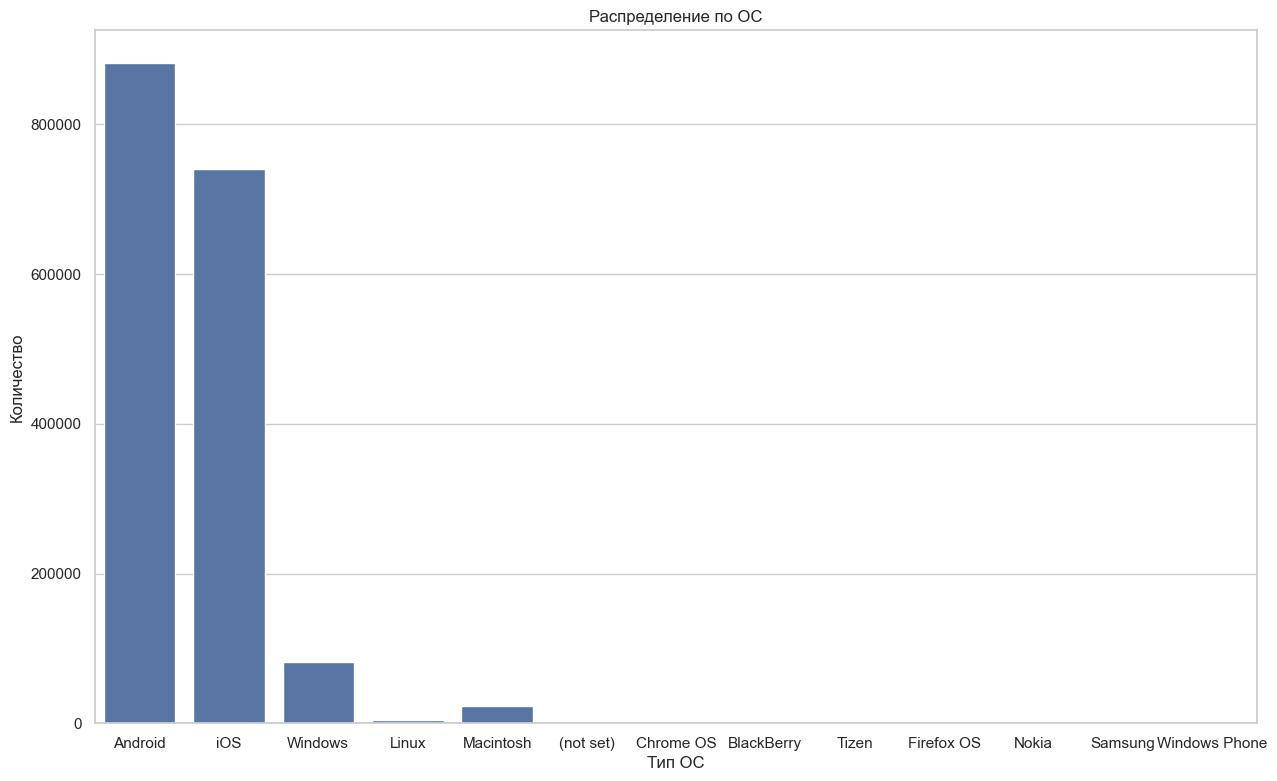

In [18]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15,9))
sns.countplot(data = df1, x = 'device_os')
plt.title('Распределение по ОС')
plt.xlabel('Тип ОС')
plt.ylabel('Количество')
plt.show()

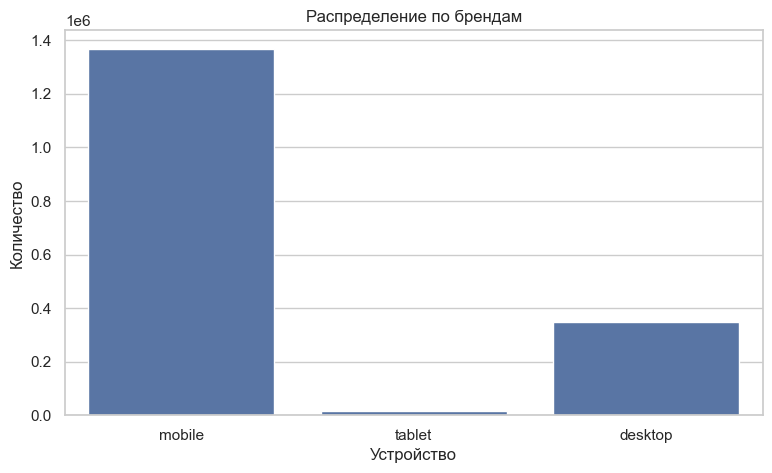

In [19]:
plt.figure(figsize=(9,5))
sns.countplot(data = df1, x = 'device_category')
plt.title('Распределение по брендам')
plt.xlabel('Устройство')
plt.ylabel('Количество')
plt.show()

**Modeling**

In [20]:
x = df1[feauters]
y = df1['event_value']

In [22]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [23]:
x_train_enc = encoder.fit_transform(x_train, y_train)

In [24]:
x_enc_test = encoder.transform(x_test)

In [25]:
model_rf = RandomForestClassifier (
    n_estimators=100,
    bootstrap=True,       
    max_samples=0.1,       
    random_state=42,
    n_jobs=-1)
logreg_sgd = SGDClassifier(
    loss='log_loss',  
    max_iter=20,      
    learning_rate='optimal',
    random_state=42,
    n_jobs=-1)


In [26]:
model_rf.fit(x_train_enc, y_train)
logreg_sgd.fit(x_train_enc, y_train)


,loss,'log_loss'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,20
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,-1


In [27]:
pred_rf = model_rf.predict(x_enc_test)
pred_log = logreg_sgd.predict(x_enc_test)

In [28]:
accuracy_rf = accuracy_score(y_test, pred_rf)
accuracy_log = accuracy_score(y_test, pred_log)

In [29]:
print(f'{accuracy_rf:.4f}')

0.7049


In [30]:
print(f'{accuracy_log:.4f}')

0.6832


In [31]:
y_pred_proba_rf = model_rf.predict_proba(x_enc_test)[:, 1]
auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
y_pred_proba_log = logreg_sgd.predict_proba(x_enc_test)[:, 1]
auc_log = roc_auc_score(y_test, y_pred_proba_log)

In [32]:
print(f"AUC-ROC-RF: {auc_rf:.4f}, AUC-ROC-LOG: {auc_log:.4f}")

AUC-ROC-RF: 0.7783, AUC-ROC-LOG: 0.7490


In [33]:
param_grid = {
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10]
}

In [34]:
rf_boost = RandomForestClassifier ()

In [35]:
x_sample, y_sample = x_train_enc[:100000], y_train[:100000]

In [36]:
hg = HalvingGridSearchCV(estimator = rf_boost, param_grid = param_grid, resource = 'n_estimators', 
                                           max_resources = 300, min_resources = 100, factor = 2, cv = 3, n_jobs=-1, random_state = 42)

In [37]:
hg.fit(x_sample, y_sample)

,estimator,RandomForestClassifier()
,param_grid,"{'max_depth': [5, 10, ...], 'min_samples_split': [2, 5, ...]}"
,factor,2
,resource,'n_estimators'
,max_resources,300
,min_resources,100
,aggressive_elimination,False
,cv,3
,scoring,None
,refit,True
,error_score,nan


In [38]:
model_rf_boost = RandomForestClassifier (
    n_estimators=200,
    max_depth = 15,
    bootstrap=True,       
    max_samples=0.1,       
    random_state=42,
    min_samples_split= 5,	
    n_jobs=-1)

In [39]:
model_rf_boost.fit(x_train_enc, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,15
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [40]:
pred_boost = model_rf_boost.predict(x_enc_test)

In [41]:
accuracy_boost = accuracy_score(y_test, pred_boost)
accuracy_boost

0.7058137588251254

In [42]:
proba_boost = model_rf_boost.predict_proba(x_enc_test)[:, 1]

In [43]:
roc_boost = roc_auc_score(y_test, proba_boost)

In [44]:
print(f"AUC-ROC-RF: {roc_boost:.4f}")

AUC-ROC-RF: 0.7796


In [48]:
pipeline = Pipeline([('encoder', TargetEncoder(smoothing = 10)), ('classifier',RandomForestClassifier (
    n_estimators=200,
    max_depth = 15,
    bootstrap=True,       
    max_samples=0.1,       
    random_state=42,
    min_samples_split= 5,	
    n_jobs=-1))])

In [49]:
pipeline.fit(x_train, y_train)

,steps,"[('encoder', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,verbose,0
,cols,"['utm_source', 'utm_medium', ...]"
,drop_invariant,False
,return_df,True
,handle_missing,'value'
,handle_unknown,'value'
,min_samples_leaf,20


In [52]:
joblib.dump(pipeline, 'model.pkl')

['model.pkl']